DATASET principal data (kaggle hackaton:)

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa



In [43]:

# Base folder that contains class subfolders (asthma, copd, etc.)
base_data_dir = Path("data")

label_map = {
    "asthma": "Asthma",
    "copd": "COPD",
    "bronchial": "Bronchial",
    "pneumonia": "Pneumonia",
    "healthy": "Healthy",
}

rows = []

for wav_path in base_data_dir.rglob("*.wav"):
    folder_name = wav_path.parent.name.lower()
    label = label_map.get(folder_name, wav_path.parent.name)

    with contextlib.closing(wave.open(str(wav_path), "rb")) as wav_file:
        sample_rate = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        duration_sec = n_frames / float(sample_rate) if sample_rate else 0.0

    # Relative path inside the stage after PUT data/*.wav @audio_stage
    file_path = str(wav_path.as_posix())

    rows.append(
        {
            "file_name": wav_path.name,
            "label": label,
            "duration_sec": duration_sec,
            "sample_rate": sample_rate,
            "file_path": file_path,
        }
    )

df = pd.DataFrame(rows).sort_values(["label", "file_name"]).reset_index(drop=True)
df


,file_name,label,duration_sec,sample_rate,file_path
0,P10AsthmaIE_49.wav,Asthma,3.136000,4000,data/asthma/P10AsthmaIE_49.wav
1,P10AsthmaIU_46.wav,Asthma,4.944000,4000,data/asthma/P10AsthmaIU_46.wav
2,P10AsthmaIU_50.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaIU_50.wav
3,P10AsthmaRL_47.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaRL_47.wav
4,P10AsthmaRS_48.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaRS_48.wav
...,...,...,...,...,...
1206,P9Pneumonia63O.wav,Pneumonia,4.922154,44100,data/pneumonia/P9Pneumonia63O.wav
1207,P9Pneumonia67I.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia67I.wav
1208,P9Pneumonia73J.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia73J.wav
1209,P9Pneumonia74S.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia74S.wav


Dataset data2 (Chest Wall Lung Sound Dataset)

In [44]:
from pathlib import Path
import pandas as pd
import re
import wave
import contextlib

def extract_label_from_filename(filename: str):
    name = Path(filename).stem
    name = re.sub(r"^BP\d+_", "", name, flags=re.IGNORECASE)
    return name.split(",")[0].strip()

rows = []

base_dir = Path("data_2")

for wav_path in base_dir.rglob("*.wav"):
    label = extract_label_from_filename(wav_path.name)

    # lecture rapide sans librosa (plus léger)
    with contextlib.closing(wave.open(str(wav_path), "rb")) as f:
        sr = f.getframerate()
        n_frames = f.getnframes()
        duration = n_frames / float(sr) if sr else 0

    rows.append({
        "file_name": wav_path.name,
        "label_raw": label,
        "duration_sec": duration,
        "sample_rate": sr,
        "path": str(wav_path)
    })

df_data2 = pd.DataFrame(rows)
df_data2.head()



,file_name,label_raw,duration_sec,sample_rate,path
0,"DP93_N,N,P R M,75,M.wav",DP93_N,9.840,4000,"data_2/Audio Files/DP93_N,N,P R M,75,M.wav"
1,"BP53_asthma,E W,P R M,72,F.wav",asthma,8.688,4000,"data_2/Audio Files/BP53_asthma,E W,P R M,72,F.wav"
2,"EP108_COPD,E W,P R L ,63,M.wav",EP108_COPD,22.832,4000,"data_2/Audio Files/EP108_COPD,E W,P R L ,63,M.wav"
3,"BP70_N,N,P L U,52,F.wav",N,13.744,4000,"data_2/Audio Files/BP70_N,N,P L U,52,F.wav"
4,"EP32_N,N,A R L,30,M.wav",EP32_N,18.352,4000,"data_2/Audio Files/EP32_N,N,A R L,30,M.wav"


On normalise + regroupe les labels


In [45]:
df_data2['sample_rate'].value_counts()

sample_rate
4000    336
Name: count, dtype: int64

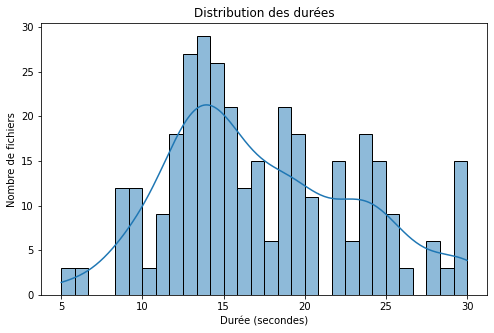

'\nplt.figure(figsize=(10, 4))\n        librosa.display.waveshow(y, sr=sr)\n        plt.ylim(-global_max_abs, global_max_abs)\n        plt.title(f"Waveform - {category_name}")\n        plt.xlabel("Time (s)")\n        plt.ylabel("Amplitude")\n        plt.tight_layout()\n        plt.show()'

In [46]:
plt.figure(figsize=(8, 5))
sns.histplot(df_data2["duration_sec"], bins=30, kde=True)
plt.title("Distribution des durées")
plt.xlabel("Durée (secondes)")
plt.ylabel("Nombre de fichiers")
plt.show()

'''
plt.figure(figsize=(10, 4))
        librosa.display.waveshow(y, sr=sr)
        plt.ylim(-global_max_abs, global_max_abs)
        plt.title(f"Waveform - {category_name}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()'''

On vérifie que les données ne sont pas les mêmes et que notre nouveau dataset est un vrai ajour pertinent

In [47]:
set_df = set(df["file_name"])
set_data2 = set(df_data2["file_name"])

common_files = set_df.intersection(set_data2)

print(f"Nombre de fichiers communs : {len(common_files)}")

Nombre de fichiers communs : 0


In [48]:
df_merge = df.merge(
    df_data2,
    on=["duration_sec", "sample_rate"],
    how="inner",
    suffixes=("_df", "_data2")
)

len(df_merge)

9

In [49]:
import hashlib

def hash_audio(file_path):
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()
    
df["hash"] = df["file_path"].apply(hash_audio)
df_data2["hash"] = df_data2["path"].apply(hash_audio)

common_hashes = set(df["hash"]).intersection(set(df_data2["hash"]))

print(f"Nombre de vrais doublons audio : {len(common_hashes)}")

Nombre de vrais doublons audio : 2


In [50]:
def get_mfcc_signature(file_path):
    y, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return np.mean(mfcc, axis=1)  # signature compacte

def similarity(sig1, sig2):
    return np.linalg.norm(sig1 - sig2)


sig_data = [get_mfcc_signature(p) for p in df["file_path"][:50]]
sig_data2 = [get_mfcc_signature(p) for p in df_data2["path"][:50]]

for i, s1 in enumerate(sig_data):
    for j, s2 in enumerate(sig_data2):
        if similarity(s1, s2) < 5:  # seuil à ajuster
            print("Possible overlap:", i, j)


Possible overlap: 2 5
Possible overlap: 3 1
Possible overlap: 46 27


On prépare data2 pour le merger à data